Using compute target: cpu
Training 2D Score Network...
Iteration 1000/6000 | Average Objective: 0.25901
Iteration 2000/6000 | Average Objective: 0.23962
Iteration 3000/6000 | Average Objective: 0.23784
Iteration 4000/6000 | Average Objective: 0.23559
Iteration 5000/6000 | Average Objective: 0.23510
Iteration 6000/6000 | Average Objective: 0.23468
Generating Samples via Reverse SDE...


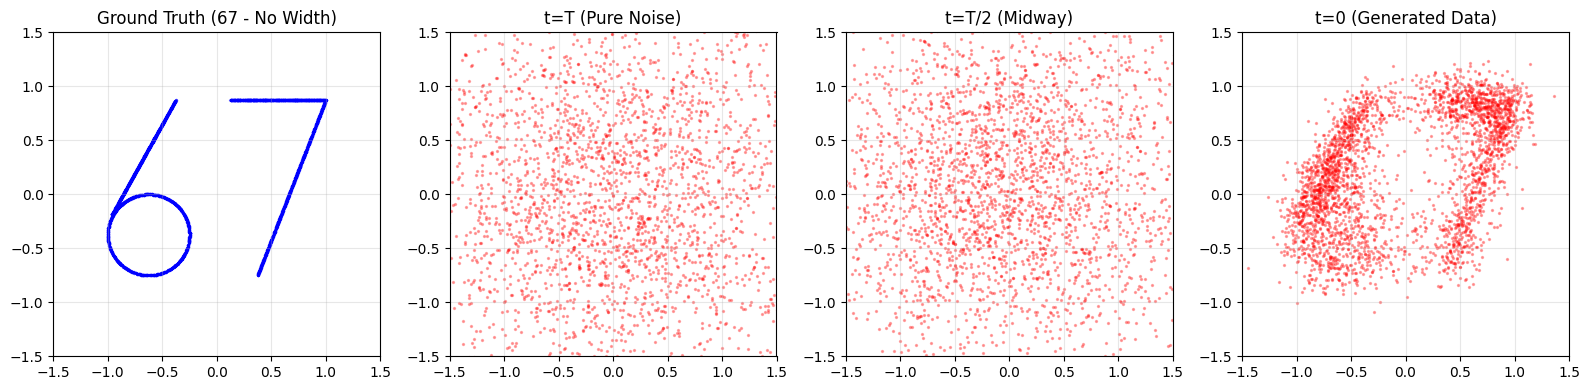

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import math

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Global Continuous OU Parameters
beta = 2.0  # Constant diffusion schedule parameter 
T = 1.0     # Max forward process distribution limit
t_eps = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute target: {device}")

# ==========================================
# 1. Distribution Environment (67 with No Width)
# ==========================================
def sample_67(batch_size):
    """Draw empirical batch conditions from original coordinates of '67'."""
    n_loop = int(batch_size * 0.3)
    n_stem = int(batch_size * 0.25)
    n_top = int(batch_size * 0.2)
    n_diag = batch_size - n_loop - n_stem - n_top
    
    # '6' Loop (circle)
    theta = torch.rand(n_loop, device=device) * 2 * math.pi
    loop_x = -0.5 + 0.3 * torch.cos(theta)
    loop_y = -0.3 + 0.3 * torch.sin(theta)
    
    # '6' stem (line)
    t1 = torch.rand(n_stem, device=device)
    stem_x = -0.77 + t1 * 0.47
    stem_y = -0.15 + t1 * 0.85

    # '7' top bar (line)
    t2 = torch.rand(n_top, device=device)
    top_x = 0.1 + t2 * 0.7
    top_y = 0.7 + torch.zeros(n_top, device=device)

    # '7' diagonal (line)
    t3 = torch.rand(n_diag, device=device)
    diag_x = 0.8 - t3 * 0.5
    diag_y = 0.7 - t3 * 1.3

    x = torch.cat([loop_x, stem_x, top_x, diag_x])
    y = torch.cat([loop_y, stem_y, top_y, diag_y])
    
    data = torch.stack([x, y], dim=1)
    # No width given: No noise addition
    data = data / torch.max(torch.abs(data))
    return data

# ==========================================
# 2. Model Structure & Training Loop
# ==========================================
class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 2)
        )
        
    def forward(self, x, t):
        # Basic concatenation MLP (no sinusoidal embedding)
        return self.net(torch.cat([x, t], dim=-1))

model = ScoreNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

iterations = 6000
batch_size = 1000
loss_history = []

model.train()
print("Training 2D Score Network...")
for i in range(iterations):
    optimizer.zero_grad()
    
    # 1. Sample arbitrary times across distributions
    t = torch.rand(batch_size, 1, device=device) * (T - t_eps) + t_eps
    
    # 2. Extract batch starting conditions
    x_0 = sample_67(batch_size)
    
    # 3. Pull random variable epsilon condition
    epsilon = torch.randn_like(x_0)
    
    # 4. Integrate determinism over variance limits
    alpha_t = torch.exp(-0.5 * beta * t)
    sigma_t = torch.sqrt(1.0 - torch.exp(-beta * t))
    
    # Apply precise variable scaling 
    x_t = alpha_t * x_0 + sigma_t * epsilon
    
    # 5. Evaluate substitute target map functions
    score_pred = model(x_t, t)
    
    # 6. Apply identical equivalent reduction to weighted objective:
    loss = torch.mean((sigma_t * score_pred + epsilon) ** 2)
    
    # 7. Update parameters
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if (i + 1) % 1000 == 0:
        print(f"Iteration {i+1:04d}/{iterations} | Average Objective: {np.mean(loss_history[-1000:]):.5f}")

# ==========================================
# 3. The Reverse SDE Sampler (Langevin Dynamics)
# ==========================================
def reverse_sampler(target_score_fn, n_samples=2000, n_steps=500, return_trajectories=False):
    dt = T / n_steps
    # Start pure normal limit (t=T)
    x = torch.randn(n_samples, 2, device=device)
    trajectories = [x.clone().cpu().numpy()]
    
    for i in range(n_steps):
        t_cur = T - i * dt
        t_tensor = torch.full_like(x[:, :1], float(t_cur), device=device)
        
        with torch.no_grad():
            score = target_score_fn(x, t_tensor)
            
        # Reverse SDE equation substituting dx backwards
        f_x = -0.5 * beta * x
        g2 = beta
        drift = f_x - g2 * score
        noise = torch.randn_like(x) if i < n_steps - 1 else torch.zeros_like(x)
        
        # Applying discretized backward step (effectively -dt)
        x = x - drift * dt + math.sqrt(beta * dt) * noise
        
        if return_trajectories:
            trajectories.append(x.clone().cpu().numpy())
            
    return trajectories if return_trajectories else x.cpu()

# ==========================================
# 4. Result Visualizations
# ==========================================
print("Generating Samples via Reverse SDE...")
model.eval()
dataset = sample_67(5000).cpu().numpy()
trajectories = reverse_sampler(model, n_samples=3000, n_steps=1000, return_trajectories=True)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].scatter(dataset[:, 0], dataset[:, 1], alpha=0.3, s=2, c='blue')
axes[0].set_title("Ground Truth (67 - No Width)")

plot_steps = [0, len(trajectories)//2, -1]
titles = ["t=T (Pure Noise)", "t=T/2 (Midway)", "t=0 (Generated Data)"]

for idx, (ax, step, title) in enumerate(zip(axes[1:], plot_steps, titles)):
    ax.scatter(trajectories[step][:, 0], trajectories[step][:, 1], alpha=0.3, s=2, c='red')
    ax.set_title(title)
    
for ax in axes:
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.grid(alpha=0.3)
    
plt.tight_layout()
plt.show()

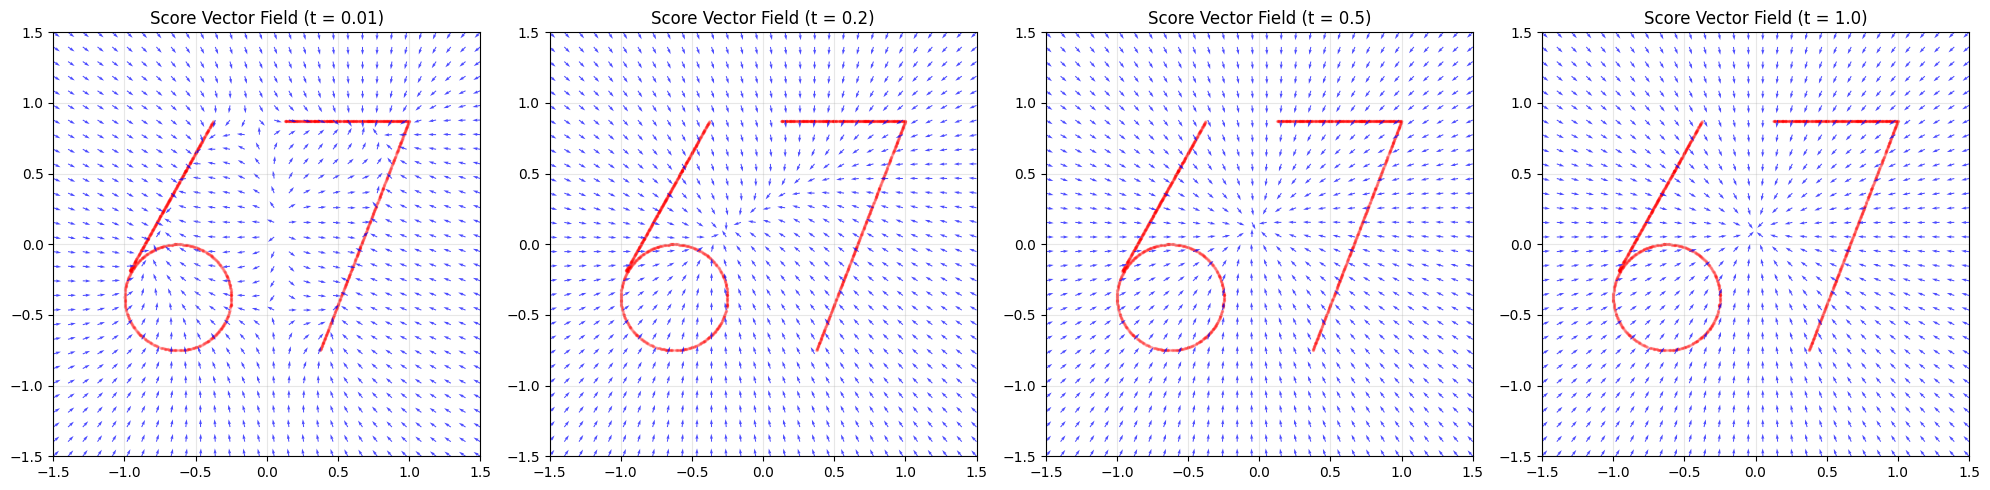

In [16]:
# ==========================================
# 5. Score Function Visualization
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
import torch

# Choose different time steps (t) to visualize
t_values = [0.01, 0.2, 0.5, 1.0]

# Create a 2D grid
grid_res = 30
x_grid, y_grid = np.meshgrid(np.linspace(-1.5, 1.5, grid_res), 
                             np.linspace(-1.5, 1.5, grid_res))
grid_points = np.stack([x_grid.flatten(), y_grid.flatten()], axis=1)
grid_tensor = torch.tensor(grid_points, dtype=torch.float32, device=device)

fig, axes = plt.subplots(1, len(t_values), figsize=(5 * len(t_values), 5))
if len(t_values) == 1:
    axes = [axes]

model.eval()
with torch.no_grad():
    for ax, t_val in zip(axes, t_values):
        # Prepare time conditions
        t_tensor = torch.full((grid_tensor.shape[0], 1), t_val, device=device)
        
        # Query the network for the score at this time step
        score_pred = model(grid_tensor, t_tensor).cpu().numpy()
        
        # Extract vector components
        u = score_pred[:, 0].reshape(grid_res, grid_res)
        v = score_pred[:, 1].reshape(grid_res, grid_res)
        
        # (Optional) Normalize the arrows so we can clearly see the direction
        magnitudes = np.sqrt(u**2 + v**2)
        u_norm = u / (magnitudes + 1e-5)
        v_norm = v / (magnitudes + 1e-5)
        
        # Plot identical reference data underneath
        ax.scatter(dataset[:, 0], dataset[:, 1], alpha=0.05, s=2, c='red')
        
        # Overlay the score field
        ax.quiver(x_grid, y_grid, u_norm, v_norm, color='blue', alpha=0.7, angles='xy')
        
        ax.set_title(f"Score Vector Field (t = {t_val})")
        ax.set_xlim(-1.5, 1.5)
        ax.set_ylim(-1.5, 1.5)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()